In [ ]:
# MNIST CNN

# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print('Using GPU')
elif torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not built; using CPU.")
        device = torch.device('cpu')
    else:
        device = torch.device('mps')
        print('Using MPS')
else:
    device = torch.device('cpu')
    print('Using CPU')

Using CPU


In [ ]:
# Data transforms
transform = transforms.ToTensor()

# Load MNIST dataset
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='data', train=False, download=True, transform=transform)


Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found




13.9%

100.0%


Extracting data\MNIST\raw\t10k-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting data\MNIST\raw\t10k-labels-idx1-ubyte.gz to data\MNIST\raw



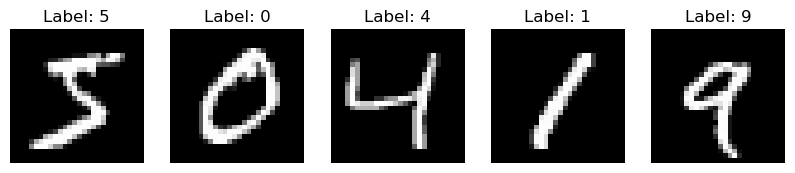

In [ ]:
# Data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Plot a few sample images
def plot_sample_images(dataset, indices):
    plt.figure(figsize=(10, 2))
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices), i + 1)
        plt.imshow(dataset.data[idx], cmap='gray')
        plt.title(f"Label: {dataset.targets[idx]}")
        plt.axis('off')
    plt.show()

plot_sample_images(train_dataset, [0, 1, 2, 3, 4])

In [ ]:
# Define CNN model
class CNN(nn.Module):
    def __init__(self, nout=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # -> [16, 28, 28]
        self.pool = nn.MaxPool2d(2, 2)                            # -> [16, 14, 14]
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # -> [32, 14, 14]
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, nout)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> [16, 14, 14]
        x = self.pool(F.relu(self.conv2(x)))  # -> [32, 7, 7]
        x = torch.flatten(x, 1)               # -> [batch, 1568]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                       # logits output
        return x

# Instantiate model
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# Loss function and optimizer
lossfn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)

# Training loop
epochs = 80
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = lossfn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")


Epoch 1/80, Loss: 0.3889
Epoch 2/80, Loss: 0.3547
Epoch 3/80, Loss: 0.3304
Epoch 4/80, Loss: 0.3114
Epoch 5/80, Loss: 0.2955
Epoch 6/80, Loss: 0.2816
Epoch 7/80, Loss: 0.2694
Epoch 8/80, Loss: 0.2573
Epoch 9/80, Loss: 0.2467
Epoch 10/80, Loss: 0.2362
Epoch 11/80, Loss: 0.2268
Epoch 12/80, Loss: 0.2179
Epoch 13/80, Loss: 0.2087
Epoch 14/80, Loss: 0.2010
Epoch 15/80, Loss: 0.1935
Epoch 16/80, Loss: 0.1859
Epoch 17/80, Loss: 0.1795
Epoch 18/80, Loss: 0.1736
Epoch 19/80, Loss: 0.1677
Epoch 20/80, Loss: 0.1619
Epoch 21/80, Loss: 0.1567
Epoch 22/80, Loss: 0.1517
Epoch 23/80, Loss: 0.1471
Epoch 24/80, Loss: 0.1430
Epoch 25/80, Loss: 0.1389
Epoch 26/80, Loss: 0.1351
Epoch 27/80, Loss: 0.1313
Epoch 28/80, Loss: 0.1276
Epoch 29/80, Loss: 0.1249
Epoch 30/80, Loss: 0.1218
Epoch 31/80, Loss: 0.1187
Epoch 32/80, Loss: 0.1160
Epoch 33/80, Loss: 0.1134
Epoch 34/80, Loss: 0.1108
Epoch 35/80, Loss: 0.1083
Epoch 36/80, Loss: 0.1060
Epoch 37/80, Loss: 0.1039
Epoch 38/80, Loss: 0.1017
Epoch 39/80, Loss: 0.

In [ ]:
# Evaluation loop
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Accuracy on test set: {accuracy:.2f}%")

Accuracy on test set: 98.25%
